In [39]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap

class LeakyIntegrateAndFireNeuron:
    def __init__(self, threshold, membrane_resistance, membrane_time_constant):
        self.threshold = threshold
        self.membrane_resistance = membrane_resistance
        self.membrane_time_constant = membrane_time_constant
        self.membrane_potential = 0.0

    def integrate(self, input_current, time_step):
        # Ensure input_current is a 1D array
        input_current = jnp.squeeze(input_current)

        # Update membrane potential using the leaky integration equation
        self.membrane_potential += (input_current / self.membrane_resistance - 
                                    self.membrane_potential / self.membrane_time_constant) * time_step

        # Check if the neuron has fired
        spike_prob = 1.0 / (1.0 + jnp.exp(-10.0 * (self.membrane_potential - self.threshold)))
        spike = jax.random.bernoulli(jax.random.PRNGKey(0), spike_prob)
        self.membrane_potential = jnp.where(spike, 0.0, self.membrane_potential)  # Reset membrane potential after firing

        return jnp.array(spike_prob, dtype=jnp.float32)  # Output 1.0 for spike, 0.0 otherwise



@jit
def classify(input_pattern, synapse_input_hidden, synapse_hidden_output, time_step=0.5):
    # Create LIF neurons for input, hidden, and output layers
    input_neuron = LeakyIntegrateAndFireNeuron(threshold=0.5, membrane_resistance=1.0, membrane_time_constant=1.0)
    hidden_neuron = LeakyIntegrateAndFireNeuron(threshold=0.5, membrane_resistance=1.0, membrane_time_constant=1.0)
    output_neuron = LeakyIntegrateAndFireNeuron(threshold=0.5, membrane_resistance=1.0, membrane_time_constant=1.0)

    # Propagate input through the network
    for _ in range(10):
        input_current_hidden = synapse_input_hidden * input_neuron.integrate(input_pattern, time_step)
        hidden_output = synapse_hidden_output * hidden_neuron.integrate(input_current_hidden, time_step)
        output = output_neuron.integrate(hidden_output, time_step)

    return output

def loss(params, inputs, labels):
    synapse_input_hidden, synapse_hidden_output = params
    predictions = vmap(classify, in_axes=(0, None, None))(inputs, synapse_input_hidden, synapse_hidden_output)
    
    # Ensure labels has the same shape as predictions
    labels = jax.nn.one_hot(labels, num_classes=2)

    return jnp.mean(jnp.square(predictions - labels))

# Using JAX's automatic differentiation to compute gradients
grad_loss = grad(loss)

def train_classifier(inputs, labels, synapse_input_hidden, synapse_hidden_output, learning_rate=0.1, num_epochs=200):
    params = (synapse_input_hidden, synapse_hidden_output)

    for epoch in range(num_epochs):
        gradients = grad_loss(params, inputs, labels)
        params = jax.tree_util.tree_map(lambda param, gradient: param - learning_rate * gradient, params, gradients)

    return params

# Test the classifier
input_patterns = jnp.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=jnp.float32)
labels = jnp.array([0, 1, 1, 0], dtype=jnp.float32)

synapse_input_hidden = 0.5
synapse_hidden_output = 0.5

trained_params = train_classifier(input_patterns, labels, synapse_input_hidden, synapse_hidden_output)

# Test the trained classifier
trained_synapse_input_hidden, trained_synapse_hidden_output = trained_params
predictions = vmap(classify, in_axes=(0, None, None))(input_patterns, trained_synapse_input_hidden, trained_synapse_hidden_output)
print("Input", input_patterns)
print("Predictions:", predictions)
print("Labels:", labels)

Input [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
Predictions: [[0.007 0.007]
 [0.007 0.537]
 [0.048 0.007]
 [0.048 0.537]]
Labels: [0. 1. 1. 0.]


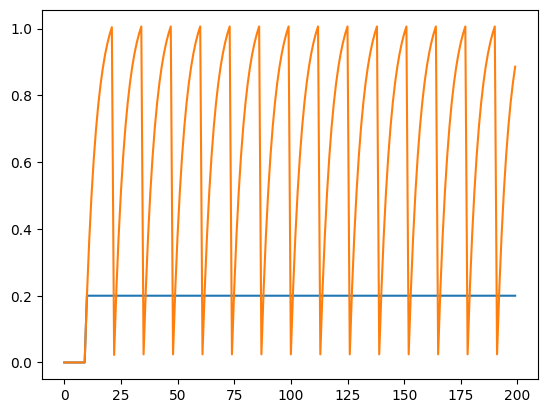

In [55]:
import matplotlib.pyplot as plt

from probjax.utils.odeint import _odeint as odeint



def lif(mem, x, beta, threshold=1.):
  spk = (mem > threshold).astype(jnp.float32) # if membrane exceeds threshold, spk=1, else, 0
  mem = beta * mem + x - spk*threshold
  return spk, mem


num_steps = 200

# initialize inputs/outputs + small step current input
x = jnp.concatenate([jnp.zeros(10), jnp.ones(190)*0.5])
mem = jnp.zeros(1)
mem_rec = []
spk_rec = []

# neuron parameters
w = 0.4
beta = 0.819

# neuron simulation
for step in range(num_steps):
  spk, mem = lif(mem, x[step]*w, beta=beta)
  mem_rec.append(mem)
  spk_rec.append(spk)

# convert lists to tensors
mem_rec = jnp.stack(mem_rec)
spk_rec = jnp.stack(spk_rec)

plt.plot(x*w)
plt.plot(mem_rec)

In [13]:
?odeint

Signature:     
odeint(
    drift,
    y0: jaxtyping.PyTree[jax.Array],
    ts: jax.Array,
    *args,
    method='rk4',
    dt: Optional[jaxtyping.Float] = None,
    rtol: float = 0.0001,
    atol: float = 1e-05,
    mxstep: int = inf,
    dtmin: float = 0.0,
    dtmax: float = inf,
    maxerror: float = 1.2,
    safety: float = 0.95,
    ifactor: float = 10.0,
    dfactor: float = 0.1,
    error_norm: float = 2,
)
Call signature: odeint(*args, **params) -> Any
Type:           custom_inverse
String form:    <probjax.core.custom_primitives.custom_inverse.custom_inverse object at 0x7f88284f9310>
File:           /mnt/qb/home/macke/mgloeckler90/probjax/probjax/utils/odeint.py
Docstring:     
Solve an ordinary differential equation.

This function assumes that y0 is a single initial value, and that ts is a single time grid, with a single set of parameters.
If you want to solve multiple ODEs, or multiple time grids, use vmap!

Args:
    drift (Callable): Drift function.
    y0 (Array): Initi